In [ ]:
import numpy as np
import pandas as pd

# 只保留sample_6相关的文件
files_sample_6 = [
    "rebuttel/WV3_Reduced/LGPNet/results/model_epoch_370/sample_0.npz",
    "rebuttel/WV3_Reduced/BWNET_LGPNet/results/model_epoch_370/sample_0.npz"
]

# 初始化数据存储
eigenvalues_sample_6 = {file: [] for file in files_sample_6}

# 读取数据并计算特征值
for file in files_sample_6:
    data = np.load(file)
    cov = data['cov'].squeeze()
    # 计算特征值
    eigenvalues_sample_6[file] = np.linalg.eigvals(cov).mean(axis=0)

# 将结果保存为CSV
eigenvalues_combined_sorted = {file: eigenvalues_sample_6[file] for file in eigenvalues_sample_6}

# 创建DataFrame
df = pd.DataFrame(eigenvalues_combined_sorted)
csv_file = "eigenvalues_sample_0.csv"
df.to_csv(csv_file, index=False)

csv_file  # 返回保存的CSV路径


'eigenvalues_sample_0.csv'

/tmp/ipykernel_130769/644891089.py:72: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect = zoom_rectangle[0]  # Access the first element of the tuple, which is the rectangle
/tmp/ipykernel_130769/644891089.py:77: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  zoom_lines = zoom_rectangle[1]  # This contains the connecting lines (ZoomEffect)


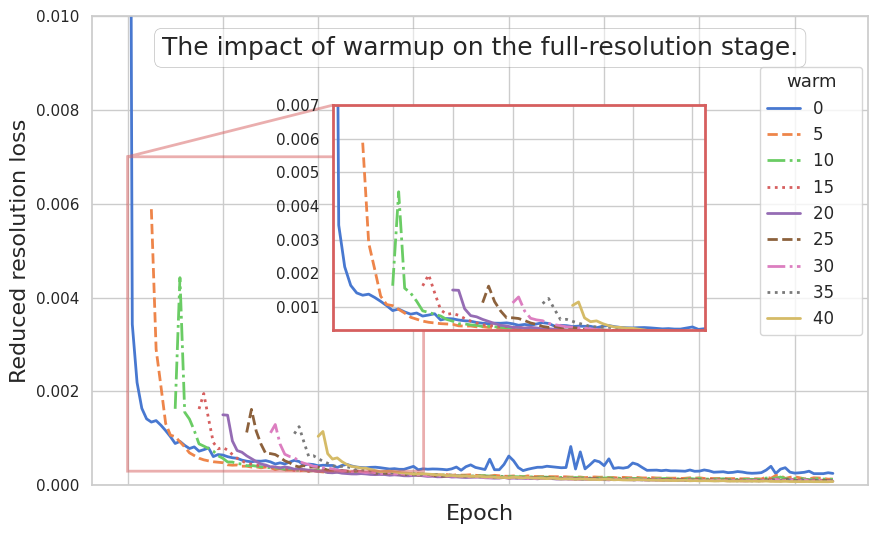

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm

# 可选：添加自定义字体
# fm.fontManager.addfont('/home/kndy666/miniconda3/envs/ML/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/times.ttf')
plt.rcParams['font.family'] = 'Times New Roman'

# 读取CSV文件，并指定空值处理
df = pd.read_csv("eigenvalues_sample_6.csv", na_values=",")

# 检查是否存在 'Step' 列，否则使用索引作为 x 轴
if 'Step' in df.columns:
    x_col = 'Step'  # 如果存在则使用 'Step'
else:
    df['Step'] = df.index  # 不存在则将索引添加为 'Step' 列
    x_col = 'Step'

# 设置 Seaborn 样式
sns.set(style="whitegrid", palette="muted")

# 定义不同的线型以便区分
line_styles = ['-', '--', '-.', ':']

# 初始化绘图
fig, ax = plt.subplots(figsize=(9, 5.5))

# 使用 Seaborn 的 lineplot 绘制每个列（除 'Step' 外）
for i, column in enumerate(df.columns):
    if column != 'Step':
        sns.lineplot(data=df, x=x_col, y=column, 
                     label=column, markers='o', markersize=6, linewidth=2, 
                     linestyle=line_styles[i % len(line_styles)], ax=ax)

# 添加标题和标签
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Reduced resolution loss',fontsize=16)
title = plt.title('The impact of warmup on the full-resolution stage.', fontsize=18, loc='center', pad=-28)
bbox_props = dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='grey', linewidth=0.5, alpha=0.5)
title.set_bbox(bbox_props)

# 在图中添加放大区域（子图）
axin = ax.inset_axes([0.31, 0.33, 0.48, 0.48])
for i, column in enumerate(df.columns):
    if column != 'Step':
        sns.lineplot(data=df, x=x_col, y=column, 
                     label=column, markers='o', markersize=6, linewidth=2, 
                     linestyle=line_styles[i % len(line_styles)], ax=axin)

# 子图细节设置：不显示图例与坐标标签
axin.legend().set_visible(False)
axin.tick_params(left=False, bottom=False, labelbottom=False)
axin.set_xticklabels([])
axin.set_xlabel('')
axin.set_ylabel('')

# 设置子图的放大区域范围
axin.set_xlim(0.01,62.127)
axin.set_ylim(0.0003, 0.007)

# 获取 Seaborn 的主题颜色
theme_color = sns.color_palette("muted")[3]

# 设置子图边框颜色和线宽
for spine in axin.spines.values():
    spine.set_edgecolor(theme_color)
    spine.set_linewidth(2)

# 添加放大框到主图，并设置边框颜色与线宽
zoom_rectangle = ax.indicate_inset_zoom(axin)
rect = zoom_rectangle[0]  # Access the first element of the tuple, which is the rectangle
rect.set_edgecolor(theme_color)  # 设置放大框的边框颜色与主题一致
rect.set_linewidth(2)            # 设置放大框的线条宽度

# Access and modify the connecting lines (ZoomEffect) directly
zoom_lines = zoom_rectangle[1]  # This contains the connecting lines (ZoomEffect)
for line in zoom_lines:
    line.set_color(theme_color)  # 设置连接线的颜色与主题一致
    line.set_linewidth(2)        # 设置连接线的宽度    

# 设置主图纵轴范围为 0 到 0.01
ax.set_ylim(0, 0.01)

# 隐藏主图的 x 轴标签
ax.set_xticklabels([])

# 设置图例位置与属性
ax.legend(title="warm", fontsize=12, title_fontsize=13, loc='upper left', bbox_to_anchor=(0.85,0.91))

# 布局调整和保存图像
plt.tight_layout()
plt.savefig("eigenvalues_sample_lgpnet.pdf")
plt.show()
